In [1]:
import urllib

import torch 

# Downloading the Data 

In [2]:
# URL = "https://www.cs.toronto.edu/~nitish/unsupervised_video/mnist_test_seq.npy"
# filename = "mnist_test_seq.npy"

# urllib.request.urlretrieve(URL, filename)

# Reading & Manipulation 

In [3]:
import numpy as np 

dataset = np.load("mnist_test_seq.npy")
print(dataset.shape)    
dataset = np.swapaxes(dataset,0,1) # Converting (T,N, H,W) --> (N,T,H,W)

train_data =dataset[:9000]
print(train_data.shape) # (N, T, H, W)

(20, 10000, 64, 64)
(9000, 20, 64, 64)


we are cutting the timeframe of a single smaple from (20 frames to 10), hence in the process doubling the sample size. 

In [4]:
train_data = np.reshape(
    train_data, [train_data.shape[0] * 2, train_data.shape[1]//2, train_data.shape[2], train_data.shape[3]]
)

train_data.shape

(18000, 10, 64, 64)

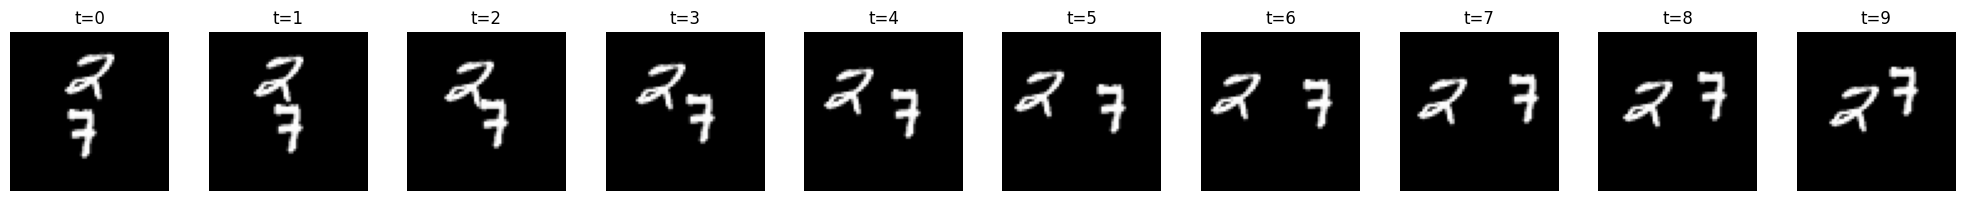

In [5]:
import matplotlib.pyplot as plt 

sample = train_data[0]
fig, axes = plt.subplots(1, 10, figsize=(20, 2))

for i in range(10):
    axes[i].imshow(sample[i], cmap="gray")
    axes[i].set_title(f"t={i}")
    axes[i].axis("off")
plt.tight_layout()

# Return Bounding Box 

### Contours 

In [29]:
import cv2 

img = train_data[5][0]

thres = (img.min() + img.max()) / 2 
contours, _ = cv2.findContours(
    (img > thres).astype("uint8"), cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE
)

contours    # [x,y] pixel coordination [x is column, y is row]

(array([[[27, 25]],
 
        [[26, 26]],
 
        [[25, 26]],
 
        [[23, 28]],
 
        [[23, 29]],
 
        [[22, 30]],
 
        [[22, 33]],
 
        [[23, 34]],
 
        [[23, 36]],
 
        [[22, 37]],
 
        [[21, 37]],
 
        [[20, 38]],
 
        [[20, 40]],
 
        [[21, 41]],
 
        [[21, 42]],
 
        [[22, 42]],
 
        [[24, 44]],
 
        [[26, 44]],
 
        [[27, 43]],
 
        [[27, 37]],
 
        [[30, 34]],
 
        [[32, 34]],
 
        [[33, 33]],
 
        [[33, 31]],
 
        [[32, 32]],
 
        [[31, 32]],
 
        [[30, 33]],
 
        [[29, 33]],
 
        [[28, 34]],
 
        [[26, 34]],
 
        [[24, 32]],
 
        [[24, 30]],
 
        [[28, 26]],
 
        [[29, 27]],
 
        [[32, 27]],
 
        [[32, 26]],
 
        [[31, 26]],
 
        [[30, 25]]], dtype=int32),
 array([[[39,  7]],
 
        [[39, 19]],
 
        [[40, 20]],
 
        [[40, 26]],
 
        [[41, 26]],
 
        [[42, 25]],
 
        [[42, 17]],

In [30]:
len(contours)   # if there is no overlap length will be 2, otherwise 1 

2

### Contour Visualization 

- `cv2.RETR_EXTERNAL` — only return the outermost contours (ignore any holes inside a digit, like the loop in a 9).

- `cv2.CHAIN_APPROX_SIMPLE` — compress the contour by storing only the corner/endpoint coordinates instead of every single pixel along the edge.

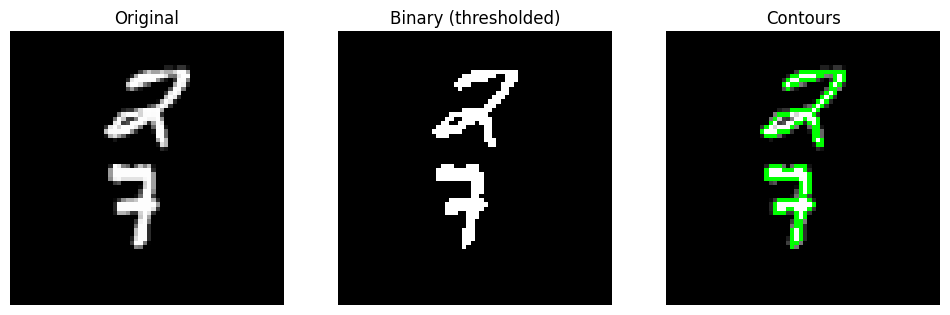

In [31]:
import cv2

frame = train_data[0][0]  # first sample, first frame

# threshold to binary
thres = (frame.min() + frame.max()) / 2
binary = (frame > thres).astype("uint8")

# find contours
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)



# draw contours on a color copy so they're visible
frame_color = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
cv2.drawContours(frame_color, contours, -1, (0, 255, 0), 1)  # green outlines


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(frame, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary (thresholded)")
axes[2].imshow(frame_color)
axes[2].set_title("Contours")
for ax in axes:
    ax.axis("off")

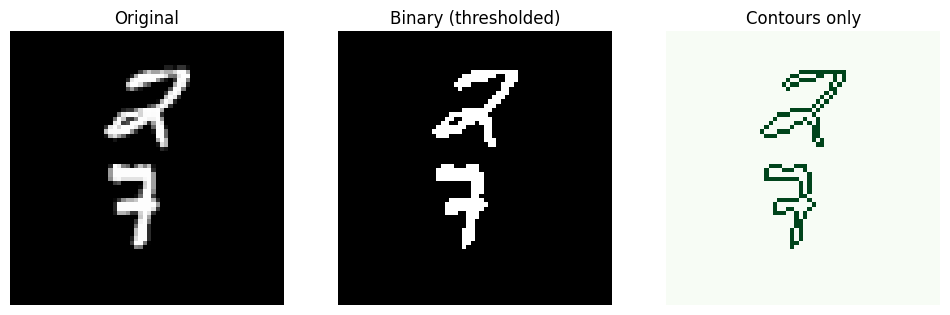

In [32]:


thres = (frame.min() + frame.max()) / 2
binary = (frame > thres).astype("uint8")

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_only = np.zeros_like(frame)
cv2.drawContours(contour_only, contours, -1, 255, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(frame, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary (thresholded)")
axes[2].imshow(contour_only, cmap="Greens")
axes[2].set_title("Contours only")
for ax in axes:
    ax.axis("off")

### Bbox 

In [33]:
bounding_boxes = []

# Loop through each contour in an image 
for cnt in contours: 
    x,y,w,h = cv2.boundingRect(cnt)
    bounding_boxes.append((x, y, x+w, y+h ))


In [34]:
bounding_boxes  # a bounding box for a single 

[(23, 31, 35, 51), (22, 9, 42, 27)]

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

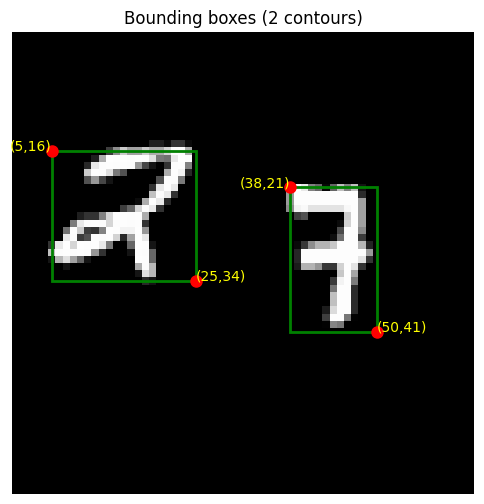

In [35]:
frame = train_data[0][5]  # t=5, digits should be apart

thres = (frame.min() + frame.max()) / 2
binary = (frame > thres).astype("uint8")
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(frame, cmap="gray")

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    rect = plt.Rectangle((x, y), w, h, edgecolor="green", facecolor="none", linewidth=2)
    ax.add_patch(rect)
    ax.plot(x, y, "ro", markersize=8)           # red dot at (x_min, y_min)
    ax.plot(x + w, y + h, "ro", markersize=8)   # red dot at (x_max, y_max)
    ax.annotate(f"({x},{y})", (x, y), color="yellow", fontsize=10, ha="right")
    ax.annotate(f"({x+w},{y+h})", (x+w, y+h), color="yellow", fontsize=10)

ax.set_title(f"Bounding boxes ({len(contours)} contours)")
ax.axis("off")

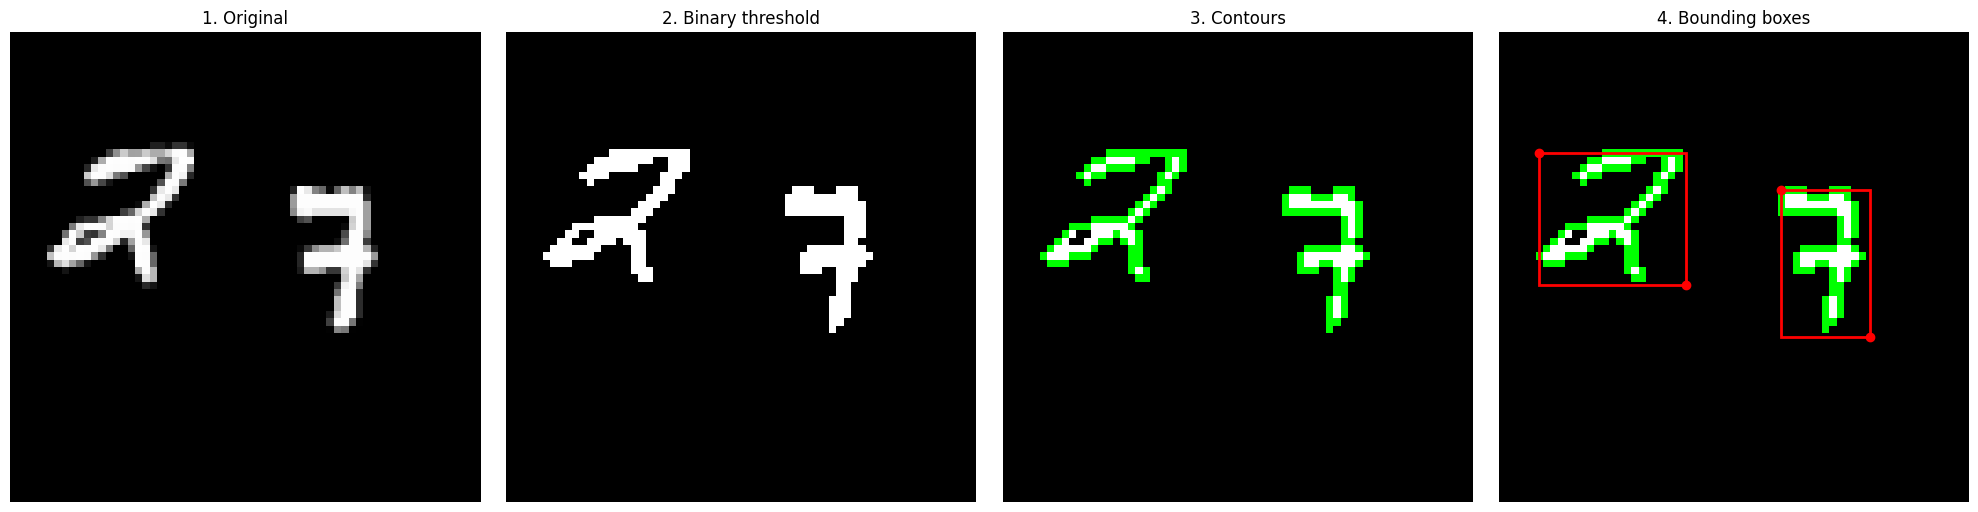

In [36]:
frame = train_data[0][5]

thres = (frame.min() + frame.max()) / 2
binary = (frame > thres).astype("uint8")
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Original
axes[0].imshow(frame, cmap="gray")
axes[0].set_title("1. Original")

# 2. Binary threshold
axes[1].imshow(binary, cmap="gray")
axes[1].set_title("2. Binary threshold")

# 3. Contours on top of binary
contour_img = cv2.cvtColor(binary * 255, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 1)
axes[2].imshow(contour_img)
axes[2].set_title("3. Contours")

# 4. Bounding boxes on top of contours
bbox_img = contour_img.copy()
axes[3].imshow(bbox_img)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
    axes[3].add_patch(rect)
    axes[3].plot(x, y, "ro", markersize=6)
    axes[3].plot(x + w, y + h, "ro", markersize=6)
axes[3].set_title("4. Bounding boxes")

for ax in axes:
    ax.axis("off")
plt.tight_layout()


# Moving MNIST Detection 

In [44]:
from moving_mnist import return_bbox

In [40]:
map_size = 8 
N,T = train_data.shape[:2]      # get the number of samples & frames 
digit_locations = torch.zeros((N,T,map_size,map_size))
print(digit_locations.shape)


torch.Size([18000, 10, 8, 8])


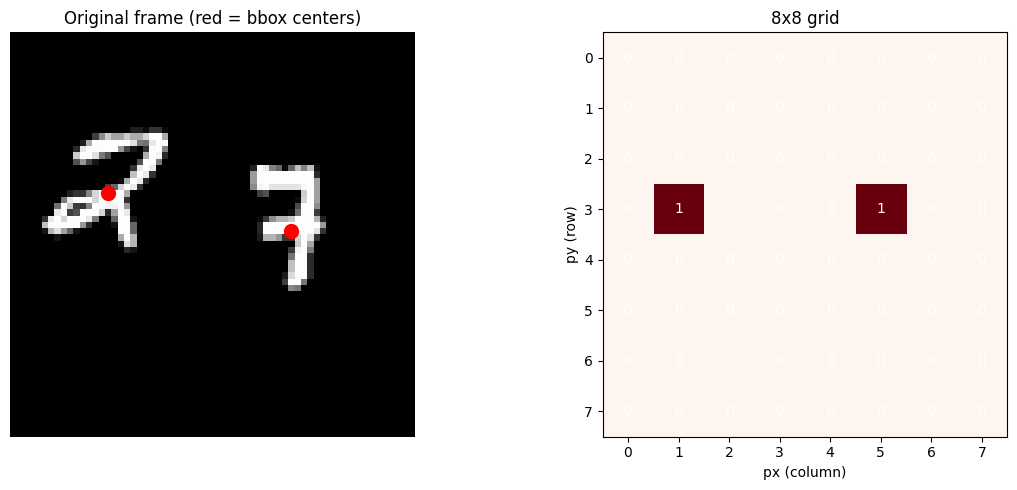

In [51]:
frame = train_data[0][5]
boxes = return_bbox(frame)

grid = torch.zeros((8, 8))
centers = []

for x1, y1, x2, y2 in boxes:
    x, y = (x1 + x2) / 2, (y1 + y2) / 2
    px = int(x / frame.shape[-1] * 8)
    py = int(y / frame.shape[-2] * 8)
    grid[py, px] = 1
    centers.append((x, y))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(frame, cmap="gray")
for cx, cy in centers:
    axes[0].plot(cx, cy, "ro", markersize=10)
axes[0].set_title("Original frame (red = bbox centers)")
axes[0].axis("off")

axes[1].imshow(grid.numpy(), cmap="Reds", vmin=0, vmax=1)
for r in range(8):
    for c in range(8):
        axes[1].text(c, r, f"{int(grid[r, c])}", ha="center", va="center", color="white", fontsize=10)
axes[1].set_title("8x8 grid")
axes[1].set_xticks(range(8))
axes[1].set_yticks(range(8))
axes[1].set_xlabel("px (column)")
axes[1].set_ylabel("py (row)")
plt.tight_layout()



In [46]:

for idx,frames in enumerate(train_data): # for each sample (10,64,64)
    for t in range(T): # for each frame 
        img = frames[t]
        boxes = return_bbox(img)
        for x1, x2, y1, y2 in boxes:
            x, y = (x1 + x2) / 2, (y1 + y2) / 2
            px = int(x / frames.shape[-1] * map_size)
            py = int(y / frames.shape[-2] * map_size)
            break 
        break 
    break 
        

In [48]:
print([idx, t, py, px])

digit_locations[idx, t, py, px] = 1 

[0, 0, 5, 3]


# Final 

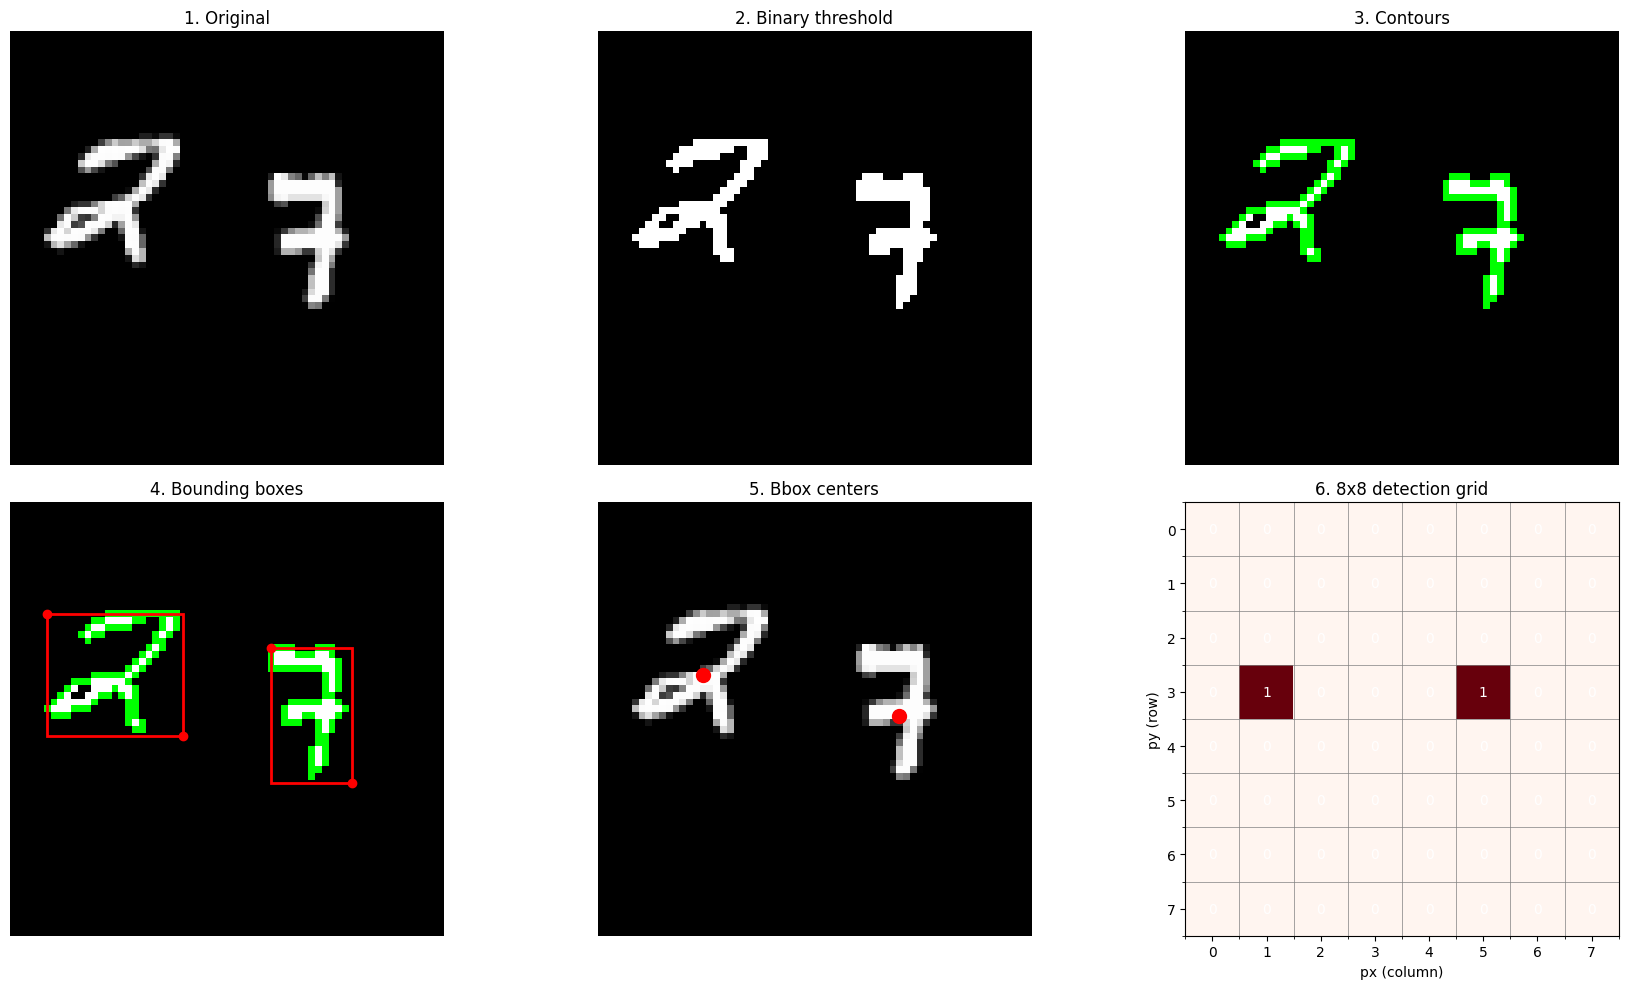

In [53]:
frame = train_data[0][5]

# threshold
thres = (frame.min() + frame.max()) / 2
binary = (frame > thres).astype("uint8")

# contours
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# bounding boxes + grid
boxes = return_bbox(frame)
map_size = 8
grid = torch.zeros((map_size, map_size))
centers = []
for x1, y1, x2, y2 in boxes:
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    px = int(cx / frame.shape[-1] * map_size)
    py = int(cy / frame.shape[-2] * map_size)
    grid[py, px] = 1
    centers.append((cx, cy))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: pipeline
# 1. Original
axes[0, 0].imshow(frame, cmap="gray")
axes[0, 0].set_title("1. Original")

# 2. Binary threshold
axes[0, 1].imshow(binary, cmap="gray")
axes[0, 1].set_title("2. Binary threshold")

# 3. Contours
contour_img = cv2.cvtColor(binary * 255, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 1)
axes[0, 2].imshow(contour_img)
axes[0, 2].set_title("3. Contours")

# Row 2
# 4. Bounding boxes
bbox_img = contour_img.copy()
axes[1, 0].imshow(bbox_img)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
    axes[1, 0].add_patch(rect)
    axes[1, 0].plot(x, y, "ro", markersize=6)
    axes[1, 0].plot(x + w, y + h, "ro", markersize=6)
axes[1, 0].set_title("4. Bounding boxes")

# 5. Frame with bbox centers
axes[1, 1].imshow(frame, cmap="gray")
for cx, cy in centers:
    axes[1, 1].plot(cx, cy, "ro", markersize=10)
axes[1, 1].set_title("5. Bbox centers")


# 6. 8x8 detection grid
axes[1, 2].imshow(grid.numpy(), cmap="Reds", vmin=0, vmax=1)
for r in range(8):
    for c in range(8):
        axes[1, 2].text(c, r, f"{int(grid[r, c])}", ha="center", va="center", color="white", fontsize=10)
axes[1, 2].set_title("6. 8x8 detection grid")
axes[1, 2].set_xticks(np.arange(-0.5, 8, 1), minor=True)
axes[1, 2].set_yticks(np.arange(-0.5, 8, 1), minor=True)
axes[1, 2].grid(which="minor", color="gray", linewidth=0.5)
axes[1, 2].set_xticks(range(8))
axes[1, 2].set_yticks(range(8))
axes[1, 2].set_xlabel("px (column)")
axes[1, 2].set_ylabel("py (row)")


for ax in axes[0]:
    ax.axis("off")
axes[1, 0].axis("off")
axes[1, 1].axis("off")





plt.tight_layout()
